In [49]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [51]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [52]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [53]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [55]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [56]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [57]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [58]:
X_train.loc[X_train['Age'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test.loc[X_test['Age'].isnull(), 'Age_imputed'] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [59]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([50.  , 27.  , 32.  , 29.  , 31.  , 45.  , 45.  , 32.  , 54.  ,
       22.  , 35.  , 29.  , 66.  , 30.  , 38.  , 18.  , 62.  , 23.  ,
       37.  , 32.  , 21.  , 39.  ,  2.  , 21.  , 42.  , 23.  , 35.  ,
       22.  , 36.  , 27.  , 50.  , 40.  , 21.  ,  8.  , 32.  , 27.  ,
       26.  , 20.  ,  8.  , 29.  , 18.  , 24.  , 31.  , 54.  , 16.  ,
       36.5 , 11.  , 41.  , 49.  , 28.  , 20.  , 47.  , 33.  , 36.  ,
       20.  ,  4.  , 28.  , 23.  , 24.  , 27.  , 28.  , 25.  ,  2.  ,
       42.  , 49.  , 38.  ,  3.  , 57.  , 25.  , 12.  , 27.  , 32.  ,
       18.  , 65.  , 31.  , 14.  , 13.  ,  9.  , 30.  , 23.  , 28.  ,
       33.  ,  0.67, 34.  , 38.  , 49.  , 18.  ,  7.  , 70.5 , 25.  ,
       30.  , 56.  , 29.  , 19.  , 36.  , 23.5 , 27.  , 22.  , 46.  ,
       18.  , 32.5 , 22.  , 30.  , 61.  , 33.  , 34.  , 24.  , 36.  ,
       32.  , 47.  , 45.  , 36.  , 19.  , 16.  , 35.  , 35.  , 56.  ,
       19.  , 19.  , 19.  , 16.  , 21.  , 65.  , 18.  , 36.  , 48.  ,
       43.  ,  9.  ,

In [60]:
X_train['Age'].isnull().sum()

np.int64(148)

In [61]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,23.0
493,71.0,49.5042,71.0
527,NaN,221.7792,25.0


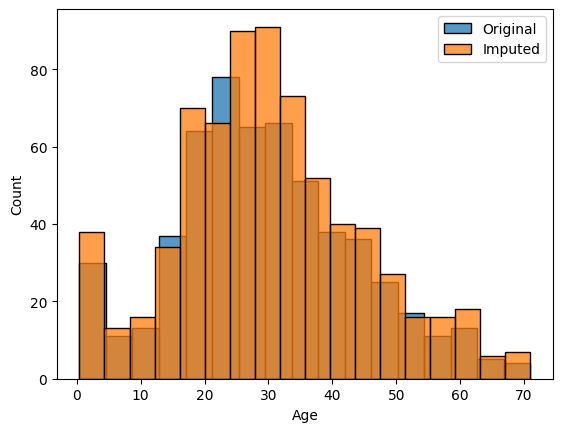

In [62]:
sns.histplot(X_train['Age'],label='Original')
sns.histplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [63]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  212.9602968107508


In [64]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,56.758788
Age,71.512440,204.349513,204.349513
Age_imputed,56.758788,204.349513,212.960297


<Axes: >

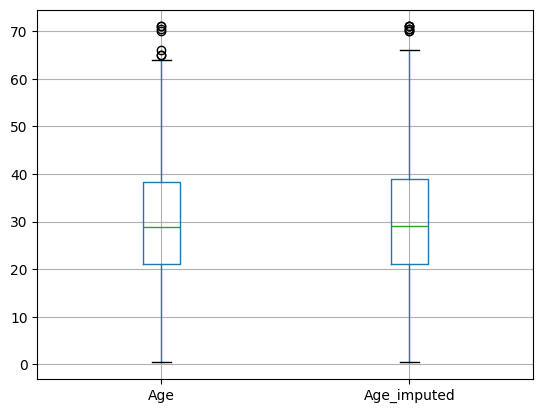

In [65]:
X_train[['Age', 'Age_imputed']].boxplot()

In [66]:
# 1. Define a sample observation (a single row)
observation = X_train.iloc[0]

# 2. Sample a random age using that passenger's Fare as the random seed
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare'])).values[0]

sampled_value


np.float64(28.0)

In [67]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [68]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [69]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [70]:
X = data
y = data['SalePrice']

In [71]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [72]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [73]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
82,Gd,TA,245000,TA,Gd
1148,Gd,TA,116900,TA,Gd
1412,NaN,TA,90000,TA,NaN
749,NaN,TA,98000,TA,NaN
954,NaN,NaN,127500,NaN,NaN


In [74]:
X_train.loc[X_train['GarageQual'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test.loc[X_test['GarageQual'].isnull(), 'GarageQual_imputed'] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train.loc[X_train['FireplaceQu'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test.loc[X_test['FireplaceQu'].isnull(), 'FireplaceQu_imputed'] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

In [75]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [76]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.036815
Gd,0.009973,0.010274
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [77]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.647587
TA,0.412439,0.542088
Fa,0.040917,0.054994
Po,0.027823,0.034792
Ex,0.024550,0.031425


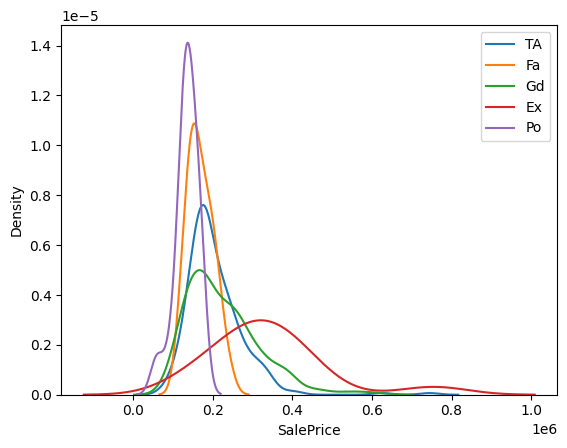

In [80]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
plt.legend()
plt.show()


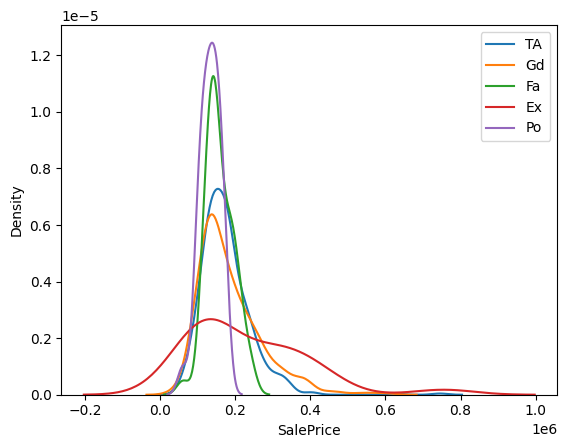

In [81]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.legend()
plt.show()
